# Counterfactual Analysis

In [16]:
import warnings
import joblib
import json
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from catboost import CatBoostClassifier


from sklearn.metrics import roc_curve, confusion_matrix, roc_auc_score

from pathlib import Path
import shutil
import sys 
sys.path.append('..')  

from module.dataload import DPN_data
import ymlconfig

import dice_ml

%matplotlib inline
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')
np.set_printoptions(precision=3)  # decimal places for outputs from numpy
pd.set_option("display.precision", 3)  # decimal places for outputs from pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load / Reload Selection Utility Functions

In [2]:
from utils2 import explainability as exp
from utils2 import counterfactuals as cf

----

## Read Config File

In [3]:
config_path = Path(r'experiments')
config_filename =  "bin_cf_final.yml"
config_dict = ymlconfig.load_config(config_path / config_filename)
config = ymlconfig.dict_to_namespace(config_dict)
config_dict


{'experiment': {'summary': 'binary classification - Counterfactual Analysis (Final)',
  'classification_type': 'binary',
  'stage': 'counterfactuals',
  'tag': 'final',
  'verbosity': 1,
  'random_seed': 42},
 'data': {'dataset_path': '../dataset/Sudoscan Working File with Stats.xlsx'},
 'model': {'code': 'catboost', 'name': 'CatBoost'},
 'explainability': {'ksplit_trained_model_results_file': 'binary\\explainability\\catboost\\final\\catboost_ksplit_trained_models.joblib',
  'rundate': '2026-03-18',
  'tag': 'final'},
 'dice': {'method': 'genetic',
  'CFs': 10,
  'diversity_weight': 1.5,
  'repeats': 1,
  'nzfill': 3,
  'heatmap': {'save_every': 15, 'figsize': {'x': 15, 'y': 6.5}},
  'sufficiency': {'maxiterations': 200},
  'necessity': {'maxiterations': 500, 'total_CFs': 2, 'nrepeats': 5}}}

#### Set output directory

In [4]:
outputdir = config_path /  config.experiment.classification_type /  config.experiment.stage / config.model.code / config.experiment.tag 
outputdir.mkdir(parents=True, exist_ok=True)
print(outputdir)

experiments\binary\counterfactuals\catboost\final


#### Copy config file to output directory

In [5]:
source = config_path / config_filename
destination = outputdir / config_filename
shutil.copy(source, destination)

WindowsPath('experiments/binary/counterfactuals/catboost/final/bin_cf_final.yml')

### Load and verify ksplit_trained_model_results_file from Explainability Stage

In [6]:
ksplit_trained_models = joblib.load(config_path / config.explainability.ksplit_trained_model_results_file)
assert ksplit_trained_models['rundate'] == config.explainability.rundate, f"{ksplit_trained_models['rundate']} != {config.explainability.rundate}"
assert ksplit_trained_models['tag'] == config.explainability.tag
print('rundate:', ksplit_trained_models['rundate'])
print('tag:', ksplit_trained_models['tag'])
ksplit_trained_models['summary']

rundate: 2026-03-18
tag: final


,0,1,2,mean,std
youden,0.909,0.727,0.784,0.807,0.076
roc_auc,0.983,0.986,0.944,0.971,0.019


In [7]:
split_results = ksplit_trained_models['results']
split_results[0]

{'model': <catboost.core.CatBoostClassifier at 0x1319f795940>,
 'X_train':      SEX   AGE  SUBJ  DM_DUR  INSULIN  HBA1C  HPN  PAOD  DSLPDMIA  CKD  GBS  \
 0      1  64.0     1     7.0      1.0  15.00    0     0         0    0    0   
 1      0  59.0     1     1.0      0.0   5.60    1     0         0    0    0   
 5      0  20.0     1     2.0      1.0   7.80    0     0         0    0    0   
 6      0  69.0     0     0.0      0.0   8.00    1     0         1    0    0   
 7      0  60.0     0     2.0      0.0   5.80    1     0         0    0    0   
 8      1  62.0     0     0.0      1.0  14.36    0     0         0    0    0   
 9      0  44.0     1    17.0      0.0   7.01    0     0         0    0    0   
 10     0  70.0     0    10.0      0.0   6.40    1     0         0    1    0   
 11     1  61.0     1     4.0      0.0   8.30    0     0         1    1    0   
 12     1  57.0     1     7.0      1.0  13.00    0     0         1    0    0   
 14     0  78.0     1     5.0      0.0   5.00 

## Data Loading

In [8]:
D = DPN_data(config.data.dataset_path)
D.load(classification=config.experiment.classification_type)

dfdpn = D.df
data_cols = dfdpn.drop(D.non_data_cols, axis=1, errors="ignore").columns
X = dfdpn[data_cols]
y = dfdpn['Confirmed_Binary_DPN']
X.shape, y.shape

((190, 40), (190,))

In [9]:
dfXy = pd.concat([X, y], axis=1)
X.shape, y.shape, dfXy.shape

((190, 40), (190,), (190, 41))

## Prepare Explainer

In [10]:
midx = 0
split_output_dir = outputdir / f'split{midx}'
split_output_dir.mkdir(parents=True, exist_ok=True)

X_test = split_results[midx]['X_test']
y_test = split_results[midx]['y_test']
threshold = split_results[midx]['threshold']
dfXy_test = pd.concat([X_test, y_test], axis=1)
X_test.shape, y_test.shape, dfXy_test.shape, threshold

((64, 40), (64,), (64, 41), 0.6352084424142594)

In [11]:
allfeature_cols = dfXy_test.columns.drop('Confirmed_Binary_DPN').to_list()
continuous_cols = dfXy_test.columns.difference(D.categorical_cols+['Confirmed_Binary_DPN']).to_list()
print('all feature columns:\n', len(allfeature_cols), allfeature_cols)
print('categorical columns:\n', len(D.categorical_cols), D.categorical_cols)
print('continuous_columns:\n', len(continuous_cols), continuous_cols)

all feature columns:
 40 ['SEX', 'AGE', 'SUBJ', 'DM_DUR', 'INSULIN', 'HBA1C', 'HPN', 'PAOD', 'DSLPDMIA', 'CKD', 'GBS', 'DEC_VS', 'DEC_PPS', 'DEC_LTS', 'DEC_AR', 'MNSI', 'SSA_L', 'SSC_L', 'SPSA_L', 'SPSC_L', 'MCV_L', 'DL_L', 'CMAPANK_L', 'CMAPKNE_L', 'FWAVE_L', 'SSA_R', 'SSC_R', 'SPSA_R', 'SPSC_R', 'MCV_R', 'DL_R', 'CMAPANK_R', 'CMAPKNE_R', 'FWAVE_R', 'FEET_MEAN_ESC', 'FEET_PCT_ASYM', 'HAND_MEAN_ESC', 'HAND_PCT_ASYM', 'NS', 'CAS']
categorical columns:
 12 ['SEX', 'SUBJ', 'INSULIN', 'HPN', 'PAOD', 'DSLPDMIA', 'CKD', 'GBS', 'DEC_VS', 'DEC_PPS', 'DEC_LTS', 'DEC_AR']
continuous_columns:
 28 ['AGE', 'CAS', 'CMAPANK_L', 'CMAPANK_R', 'CMAPKNE_L', 'CMAPKNE_R', 'DL_L', 'DL_R', 'DM_DUR', 'FEET_MEAN_ESC', 'FEET_PCT_ASYM', 'FWAVE_L', 'FWAVE_R', 'HAND_MEAN_ESC', 'HAND_PCT_ASYM', 'HBA1C', 'MCV_L', 'MCV_R', 'MNSI', 'NS', 'SPSA_L', 'SPSA_R', 'SPSC_L', 'SPSC_R', 'SSA_L', 'SSA_R', 'SSC_L', 'SSC_R']


In [12]:
X_train = split_results[midx]['X_train']
X_test = split_results[midx]['X_test']

# convert categorical columns in X_train - needed in CatBoost for use in DiCE
X_train[D.categorical_cols] = X_train[D.categorical_cols].astype(str)
X_test[D.categorical_cols] = X_test[D.categorical_cols].astype(str)

best_params = split_results[midx]['best_params']
y_train = split_results[midx]['y_train']
y_test = split_results[midx]['y_test']

# refit model so we can set cat_features (needed in DiCE)
model=  CatBoostClassifier(**best_params, 
                           cat_features=D.categorical_cols, 
                           verbose=0
                           ).fit(X_train, y_train)

## Global Counterfactual Analysis

###  Define Global Permitted Range

In [13]:
global_permitted_range = cf.get_global_permitted_range(
    dfXy, continuous_cols, config, midx, verbosity=1, savedir=split_output_dir)

,min,max
AGE,8.111,100.889
CAS,0.000,58.027
CMAPANK_L,0.000,29.589
CMAPANK_R,0.000,31.434
CMAPKNE_L,0.000,22.551
CMAPKNE_R,0.000,23.008
DL_L,0.000,48.650
DL_R,0.000,16.399
DM_DUR,0.000,37.797
FEET_MEAN_ESC,0.000,106.560


### Setup Explainer Object

In [14]:
wrapped_model = cf.CatBoostWrapper(model, threshold)
cf.test_wrapped_model(model, wrapped_model, X_test, y_test, threshold)

Confusion Matrix at default threshold (0.5):
[[20  0]
 [ 3 41]]
Confusion Matrix at custom threshold (0.6352084424142594):
[[20  0]
 [ 4 40]]
Rows with different predictions at thresholds: 


,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,pred_0.50,pred_0.64,pred_proba
106,1,33.0,1,3.0,1.0,9.0,0,0,0,0,0,0,1,0,1,3.0,4.88,49.2,0.0,0.0,43.2,3.5,13.14,10.75,43.3,2.68,45.3,0.0,0.0,44.0,3.45,9.98,7.18,42.4,76.0,0.0,76.0,12.0,90.0,4.0,1,0,0.524


### Plot Global Importances

100%|██████████| 64/64 [03:29<00:00,  3.27s/it]


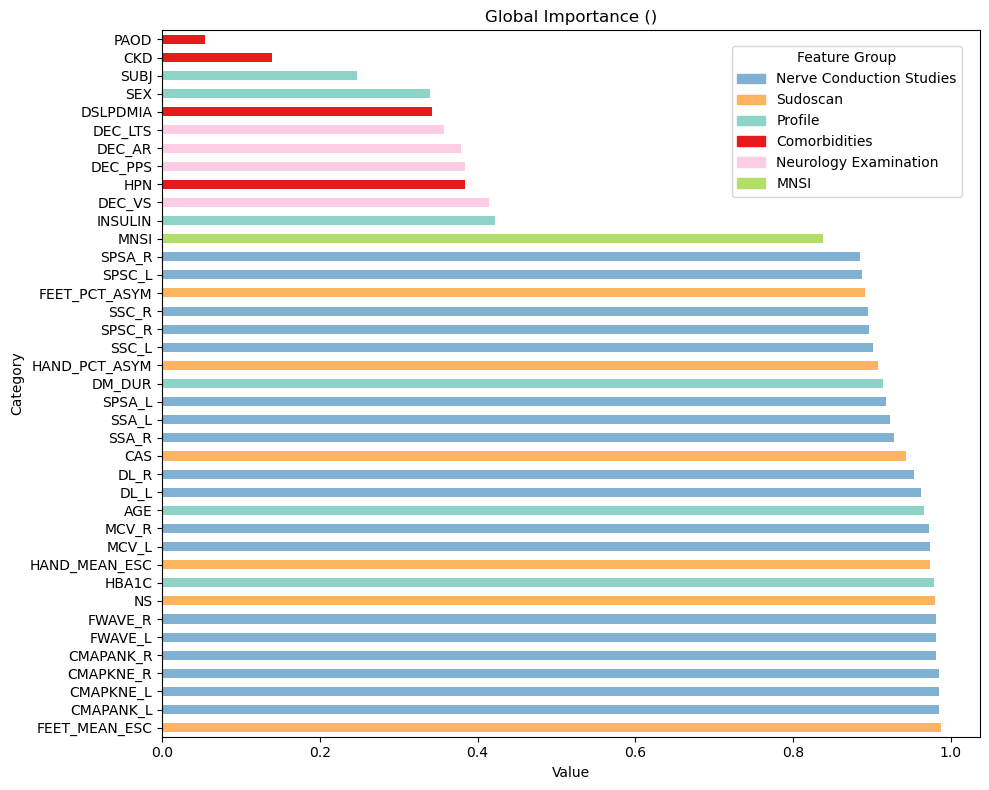

In [15]:
d = dice_ml.Data(dataframe=dfXy_test, # use only the test set
                 continuous_features=continuous_cols,                  
                 categorical_features=D.categorical_cols,
                 permitted_range = global_permitted_range, 
                 outcome_name='Confirmed_Binary_DPN')

m = dice_ml.Model(model=wrapped_model, backend="sklearn", model_type="classifier")
dexp = dice_ml.Dice(d, m, method=config.dice.method)

cf.plot_global_importance(dexp, D, X_test, config, midx, 
                        highlight_features=[], total_CFs=10, 
                        title_suffix="", filename_suffix="", savedir=split_output_dir)

## Local Counterfactual Analysis

##### Local Permitted Range for Patient Index 40

In [17]:
pidx = 4
split_instance_output_dir = split_output_dir / f'{str(pidx).zfill(3)}_temp'
split_instance_output_dir.mkdir(parents=True, exist_ok=True)

query_instance = X[pidx:pidx+1]
instance_permitted_range = cf.get_local_permitted_range(
    dfXy, query_instance, allfeature_cols, D.categorical_cols, continuous_cols, cf.progressive_cols,
    config, midx, savedir=split_instance_output_dir)

Local permitted range:


,instance,min,max
SEX,1.00,NaN,NaN
AGE,57.00,57.000,68.889
SUBJ,0.00,NaN,NaN
DM_DUR,5.00,5.000,12.797
INSULIN,1.00,NaN,NaN
HBA1C,14.40,11.685,17.115
HPN,0.00,NaN,NaN
PAOD,0.00,NaN,NaN
DSLPDMIA,0.00,NaN,NaN
CKD,0.00,NaN,NaN


##### Generate 5 Sample Local Counterfactuals for Patient 40

In [18]:
e1 = cf.generate_sample_local_cf_with_permitted_range(dfXy, dexp, query_instance, instance_permitted_range, config, CFs=3)
e1_cfdf = e1.cf_examples_list[0].final_cfs_df

generating counterfactuals for the CatBoost model


100%|██████████| 1/1 [00:01<00:00,  1.02s/it]

Query instance (original outcome : 1)


,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,1,57.0,0,5.0,1.0,14.4,0,0,0,0,0,1,0,1,1,1.0,4.19,41.9,3.7,38.2,38.5,4.5,8.89,6.88,48.3,5.36,45.5,4.42,39.5,38.3,4.0,10.29,8.82,49.9,54.0,3.0,63.0,0.0,54.0,36.0,1



Diverse Counterfactual set (new outcome: 0)


,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,-,-,1.0,-,0.0,-,-,-,-,-,-,0.0,1.0,0.0,0.0,-,4.2,46.4,-,52.8,43.5,3.85,10.28,7.51,47.3,5.4,47.1,4.4,51.4,44.4,4.6,14.42,9.02,46.1,60.0,1.0,-,-,57.0,28.0,0.0
0,-,-,-,-,0.0,11.7,1.0,-,-,-,-,0.0,-,0.0,0.0,-,0.0,46.9,5.6,42.7,-,4.3,-,9.36,44.7,14.1,54.6,6.4,45.9,45.3,4.2,8.54,8.2,44.8,48.0,-,56.0,4.0,-,44.0,0.0
0,-,59.0,1.0,-,0.0,-,-,-,-,-,-,-,1.0,-,-,3.0,10.1,51.5,4.4,59.6,-,3.25,-,10.13,45.1,13.1,54.5,5.9,52.6,-,3.6,-,10.07,46.0,40.0,9.0,52.0,5.0,50.0,37.0,0.0


In [19]:
e1_cfdf.head(2)

,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
0,1,57.0,1,5.0,0.0,14.4,0,0,0,0,0,0,1,0,0,1.0,4.2,46.4,3.7,52.8,43.5,3.85,10.28,7.51,47.3,5.4,47.1,4.4,51.4,44.4,4.6,14.42,9.02,46.1,60.0,1.0,63.0,0.0,57.0,28.0,0
0,1,57.0,0,5.0,0.0,11.7,1,0,0,0,0,0,0,0,0,1.0,0.0,46.9,5.6,42.7,38.5,4.30,8.89,9.36,44.7,14.1,54.6,6.4,45.9,45.3,4.2,8.54,8.20,44.8,48.0,3.0,56.0,4.0,54.0,44.0,0


### Borderline & Misclassified Local Counterfactuals

In [20]:
ioi_df, display_cols = cf.get_instances_of_interest(
    wrapped_model, X_test, y_test, config=config, split_index=midx, 
    threshold=threshold, delta=0.2, savedir=split_instance_output_dir)

Found 6 misclassified and borderline cases (|p - 0.6352| ≤ 0.2)


,SEX,AGE,SUBJ,DM_DUR,margin,misclassified,pred_proba,pred,actual
4,1,57.0,0,5.0,0.083,False,0.719,1,1
55,0,67.0,1,11.0,0.131,False,0.767,1,1
67,1,56.0,1,0.0,0.449,True,0.187,0,1
106,1,33.0,1,3.0,0.111,True,0.524,0,1
128,0,74.0,1,30.0,0.360,True,0.275,0,1
158,0,43.0,1,2.0,0.598,True,0.037,0,1


In [21]:
ioi_df.loc[4][['actual','pred']]

actual    1
pred      1
Name: 4, dtype: object

### Generate Local Counterfactuals

In [22]:
ioi_df

,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,pred_proba,margin,pred,actual,misclassified
4,1,57.0,0,5.0,1.0,14.4,0,0,0,0,0,1,0,1,1,1.0,4.19,41.90,3.70,38.20,38.5,4.50,8.89,6.88,48.3,5.36,45.5,4.42,39.50,38.3,4.00,10.29,8.82,49.9,54.0,3.0,63.0,0.0,54.0,36.0,0.719,0.083,1,1,False
55,0,67.0,1,11.0,0.0,11.1,1,0,1,0,0,1,1,1,1,4.0,8.74,47.50,4.03,44.50,45.2,4.85,14.13,9.15,49.2,7.24,46.5,7.04,53.10,42.5,4.00,8.42,6.23,50.0,67.0,2.0,49.0,9.0,47.0,32.0,0.767,0.131,1,1,False
67,1,56.0,1,0.0,0.0,5.1,0,0,0,0,0,0,0,0,0,3.0,16.27,52.00,12.16,50.70,46.6,3.75,9.46,6.93,47.0,13.80,50.0,13.48,53.00,43.8,3.20,7.41,5.61,47.7,71.0,8.0,63.0,6.0,60.0,30.0,0.187,0.449,0,1,True
106,1,33.0,1,3.0,1.0,9.0,0,0,0,0,0,0,1,0,1,3.0,4.88,49.20,0.00,0.00,43.2,3.50,13.14,10.75,43.3,2.68,45.3,0.00,0.00,44.0,3.45,9.98,7.18,42.4,76.0,0.0,76.0,12.0,90.0,4.0,0.524,0.111,0,1,True
128,0,74.0,1,30.0,0.0,4.9,1,0,1,0,0,0,1,1,1,4.0,14.40,47.60,11.03,45.50,45.1,3.95,10.29,7.78,46.4,7.45,46.4,11.65,48.50,42.3,3.45,7.71,5.12,46.6,46.0,0.0,60.0,0.0,34.0,30.0,0.275,0.360,0,1,True
158,0,43.0,1,2.0,0.0,5.2,0,0,1,0,0,0,0,1,0,9.0,12.19,1.96,9.78,2.38,47.2,4.15,14.75,8.91,43.3,34.31,57.7,19.70,2.58,49.3,3.45,15.36,9.43,42.9,57.0,6.0,50.0,7.0,70.0,29.0,0.037,0.598,0,1,True


#### Patient Index 4 (Patient 5 in Spreadsheet)

In [23]:
pidx = 4 # dataframe is zero-indexed

query_instance = X[pidx:pidx+1]
df_dcf = cf.generate_diverse_cfs(
    dexp,
    query_instance, 
    config,
    midx,
    total_CFs=10,
    permitted_range=instance_permitted_range,
    features_to_vary=dfXy.columns.drop(['SEX', 'Confirmed_Binary_DPN']).to_list(),
    nrepeats=1, #5
    savedir=split_instance_output_dir
    )

100%|██████████| 1/1 [01:31<00:00, 91.03s/it]


In [24]:
df_dcf.tail(3)

,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
6,1,57.0,0,5.0,0.0,14.4,0,0,0,0,0,0,0,1,0,1.0,11.9,59.8,6.1,52.8,31.8,1.35,10.28,8.50,39.2,6.2,32.9,10.4,34.0,44.4,4.45,5.6,9.02,46.1,60.0,1.0,63.0,0.0,54.0,31.0,0
7,1,60.1,0,8.7,0.0,14.4,0,0,0,0,0,0,1,0,0,1.0,11.7,45.5,10.9,44.4,38.5,3.50,4.10,8.99,53.8,5.4,45.1,0.0,24.0,38.3,4.85,5.6,8.21,41.0,55.0,0.0,63.0,0.0,60.0,30.0,0
8,1,57.0,0,5.0,0.0,14.4,0,0,0,0,0,0,0,1,1,3.0,11.9,59.8,6.1,52.8,40.5,1.35,8.89,8.50,39.2,6.2,32.9,10.4,34.0,38.3,4.45,5.6,7.00,45.3,34.4,0.0,62.0,7.0,54.0,31.0,0


In [25]:
dfXy.columns.__len__()

41

diffs.shape:  (9, 41)
batch_ranges:  [(0, 15)]
idx_start, idx_end:  0 15
diff.shape:  (9, 40)
Counterfactual heatmaps saved to catboost_split0_local_cf_qidx004_000-008.png in experiments\binary\counterfactuals\catboost\final\split0\004_temp


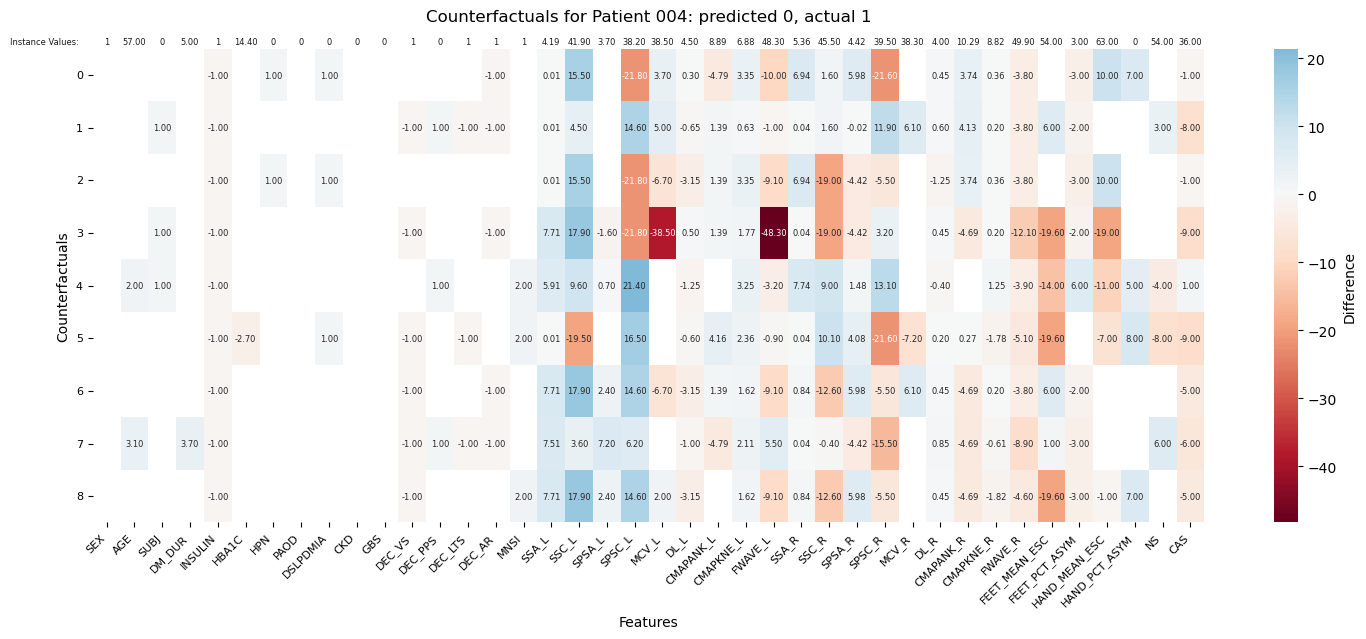

In [26]:
cf.plot_local_cf_heatmap(dfXy, df_dcf, query_instance, 
                      query_idx=pidx, pred=0, actual=1, config=config, split_index=midx,  
                      savedir=split_instance_output_dir)

##### Get Most Changed Features

In [27]:
cf.get_most_changed_feature(
    df_dcf, query_instance, config, midx, savedir=split_instance_output_dir)

SSA_L                   9
FWAVE_L                 9
SPSA_R                  9
INSULIN                 9
SSC_L                   9
DL_R                    9
DL_L                    9
SSA_R                   9
FWAVE_R                 9
SPSC_R                  9
SPSC_L                  9
Confirmed_Binary_DPN    9
CMAPKNE_R               9
CMAPKNE_L               9
CAS                     9
SSC_R                   9
CMAPANK_R               8
FEET_PCT_ASYM           8
FEET_MEAN_ESC           7
CMAPANK_L               7
MCV_L                   6
HAND_MEAN_ESC           6
DEC_VS                  6
SPSA_L                  5
DEC_AR                  5
HAND_PCT_ASYM           4
NS                      4
DSLPDMIA                3
DEC_PPS                 3
MCV_R                   3
MNSI                    3
DEC_LTS                 3
SUBJ                    3
AGE                     2
HPN                     2
HBA1C                   1
DM_DUR                  1
SEX                     0
PAOD        

##### Analyze Sparsity and L1, L2 Distances

In [28]:
diffs, cf_ana = cf.get_local_cf_distances(
    query_instance, df_dcf, config, midx, sort_by="L2_dist", 
    savedir=split_instance_output_dir)
diffs.head()

,AGE,CAS,CKD,CMAPANK_L,CMAPANK_R,CMAPKNE_L,CMAPKNE_R,Confirmed_Binary_DPN,DEC_AR,DEC_LTS,DEC_PPS,DEC_VS,DL_L,DL_R,DM_DUR,DSLPDMIA,FEET_MEAN_ESC,FEET_PCT_ASYM,FWAVE_L,FWAVE_R,GBS,HAND_MEAN_ESC,HAND_PCT_ASYM,HBA1C,HPN,INSULIN,MCV_L,MCV_R,MNSI,NS,PAOD,SEX,SPSA_L,SPSA_R,SPSC_L,SPSC_R,SSA_L,SSA_R,SSC_L,SSC_R,SUBJ,sparsity,L1_dist,L2_dist
0,0.0,-1.0,0.0,-4.79,3.74,3.35,0.36,NaN,-1.0,0.0,0.0,0.0,0.30,0.45,0.0,1.0,0.0,-3.0,-10.0,-3.8,0.0,10.0,7.0,0.0,1.0,-1.0,3.7,0.0,0.0,0.0,0.0,0.0,0.0,5.98,-21.8,-21.6,0.01,6.94,15.5,1.6,0.0,25,128.92,40.103
1,0.0,-8.0,0.0,1.39,4.13,0.63,0.20,NaN,-1.0,-1.0,1.0,-1.0,-0.65,0.60,0.0,0.0,6.0,-2.0,-1.0,-3.8,0.0,0.0,0.0,0.0,0.0,-1.0,5.0,6.1,0.0,3.0,0.0,0.0,0.0,-0.02,14.6,11.9,0.01,0.04,4.5,1.6,1.0,28,81.17,24.381
2,0.0,-1.0,0.0,1.39,3.74,3.35,0.36,NaN,0.0,0.0,0.0,0.0,-3.15,-1.25,0.0,1.0,0.0,-3.0,-9.1,-3.8,0.0,10.0,0.0,0.0,1.0,-1.0,-6.7,0.0,0.0,0.0,0.0,0.0,0.0,-4.42,-21.8,-5.5,0.01,6.94,15.5,-19.0,0.0,23,123.01,38.319
3,0.0,-9.0,0.0,1.39,-4.69,1.77,0.20,NaN,-1.0,0.0,0.0,-1.0,0.50,0.45,0.0,0.0,-19.6,-2.0,-48.3,-12.1,0.0,-19.0,0.0,0.0,0.0,-1.0,-38.5,0.0,0.0,0.0,0.0,0.0,-1.6,-4.42,-21.8,3.2,7.71,0.04,17.9,-19.0,1.0,26,237.17,77.921
4,2.0,1.0,0.0,0.00,0.00,3.25,1.25,NaN,0.0,0.0,1.0,0.0,-1.25,-0.40,0.0,0.0,-14.0,6.0,-3.2,-3.9,0.0,-11.0,5.0,0.0,0.0,-1.0,0.0,0.0,2.0,-4.0,0.0,0.0,0.7,1.48,21.4,13.1,5.91,7.74,9.6,9.0,1.0,26,130.18,36.682


In [29]:
cf_ana

,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN,sparsity,L1_dist,L2_dist
0,1,57.0,0,5.0,0.0,14.4,1,0,1,0,0,1,0,1,0,1.0,4.2,57.4,3.7,16.4,42.2,4.80,4.10,10.23,38.3,12.3,47.1,10.4,17.9,38.3,4.45,14.03,9.18,46.1,54.0,0.0,73.0,7.0,54.0,35.0,0,25,128.92,40.103
1,1,57.0,1,5.0,0.0,14.4,0,0,0,0,0,0,1,0,0,1.0,4.2,46.4,3.7,52.8,43.5,3.85,10.28,7.51,47.3,5.4,47.1,4.4,51.4,44.4,4.60,14.42,9.02,46.1,60.0,1.0,63.0,0.0,57.0,28.0,0,28,81.17,24.381
2,1,57.0,0,5.0,0.0,14.4,1,0,1,0,0,1,0,1,1,1.0,4.2,57.4,3.7,16.4,31.8,1.35,10.28,10.23,39.2,12.3,26.5,0.0,34.0,38.3,2.75,14.03,9.18,46.1,54.0,0.0,73.0,0.0,54.0,35.0,0,23,123.01,38.319
3,1,57.0,1,5.0,0.0,14.4,0,0,0,0,0,0,0,1,0,1.0,11.9,59.8,2.1,16.4,0.0,5.00,10.28,8.65,0.0,5.4,26.5,0.0,42.7,38.3,4.45,5.60,9.02,37.8,34.4,1.0,44.0,0.0,54.0,27.0,0,26,237.17,77.921
4,1,59.0,1,5.0,0.0,14.4,0,0,0,0,0,1,1,1,1,3.0,10.1,51.5,4.4,59.6,38.5,3.25,8.89,10.13,45.1,13.1,54.5,5.9,52.6,38.3,3.60,10.29,10.07,46.0,40.0,9.0,52.0,5.0,50.0,37.0,0,26,130.18,36.682
5,1,57.0,0,5.0,0.0,11.7,0,0,1,0,0,0,0,0,1,3.0,4.2,22.4,3.7,54.7,38.5,3.90,13.05,9.24,47.4,5.4,55.6,8.5,17.9,31.1,4.20,10.56,7.04,44.8,34.4,3.0,56.0,8.0,46.0,27.0,0,28,154.70,44.725
6,1,57.0,0,5.0,0.0,14.4,0,0,0,0,0,0,0,1,0,1.0,11.9,59.8,6.1,52.8,31.8,1.35,10.28,8.50,39.2,6.2,32.9,10.4,34.0,44.4,4.45,5.60,9.02,46.1,60.0,1.0,63.0,0.0,54.0,31.0,0,25,120.73,33.291
7,1,60.1,0,8.7,0.0,14.4,0,0,0,0,0,0,1,0,0,1.0,11.7,45.5,10.9,44.4,38.5,3.50,4.10,8.99,53.8,5.4,45.1,0.0,24.0,38.3,4.85,5.60,8.21,41.0,55.0,0.0,63.0,0.0,60.0,30.0,0,28,101.12,26.284
8,1,57.0,0,5.0,0.0,14.4,0,0,0,0,0,0,0,1,1,3.0,11.9,59.8,6.1,52.8,40.5,1.35,8.89,8.50,39.2,6.2,32.9,10.4,34.0,38.3,4.45,5.60,7.00,45.3,34.4,0.0,62.0,7.0,54.0,31.0,0,25,134.56,38.006


#### Filter Valid Counterfactuals

In [30]:
query_instance

,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS
4,1,57.0,0,5.0,1.0,14.4,0,0,0,0,0,1,0,1,1,1.0,4.19,41.9,3.7,38.2,38.5,4.5,8.89,6.88,48.3,5.36,45.5,4.42,39.5,38.3,4.0,10.29,8.82,49.9,54.0,3.0,63.0,0.0,54.0,36.0


In [31]:
list(set(cf.progressive_cols) & set(D.categorical_cols))

['CKD', 'PAOD', 'DEC_PPS', 'HPN', 'GBS', 'DEC_VS', 'DEC_LTS', 'DEC_AR']

In [32]:
df_dcf2 = cf.filter_invalid_progressive_cfs(df_dcf, query_instance, D.categorical_cols)
df_dcf2

Checking for invalid counterfactuals in these columns:
 ['CKD', 'PAOD', 'DEC_PPS', 'HPN', 'GBS', 'DEC_VS', 'DEC_LTS', 'DEC_AR']
Removed 7 invalid progressive counterfactuals


,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN,sparsity,L1_dist,L2_dist
2,1,57.0,0,5.0,0.0,14.4,1,0,1,0,0,1,0,1,1,1.0,4.2,57.4,3.7,16.4,31.8,1.35,10.28,10.23,39.2,12.3,26.5,0.0,34.0,38.3,2.75,14.03,9.18,46.1,54.0,0.0,73.0,0.0,54.0,35.0,0,23,123.01,38.319
4,1,59.0,1,5.0,0.0,14.4,0,0,0,0,0,1,1,1,1,3.0,10.1,51.5,4.4,59.6,38.5,3.25,8.89,10.13,45.1,13.1,54.5,5.9,52.6,38.3,3.60,10.29,10.07,46.0,40.0,9.0,52.0,5.0,50.0,37.0,0,26,130.18,36.682


In [33]:
# check by manually updating a proressive column from the query instance
query_instance2 = query_instance.copy()
# set progressive column to 1 so we can check 
# if there are counterfactuals that set it to 0 and are thus invalid
query_instance2.HPN = 1 
query_instance2

,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS
4,1,57.0,0,5.0,1.0,14.4,1,0,0,0,0,1,0,1,1,1.0,4.19,41.9,3.7,38.2,38.5,4.5,8.89,6.88,48.3,5.36,45.5,4.42,39.5,38.3,4.0,10.29,8.82,49.9,54.0,3.0,63.0,0.0,54.0,36.0


In [34]:
cf.filter_invalid_progressive_cfs(df_dcf, query_instance2, D.categorical_cols)

Checking for invalid counterfactuals in these columns:
 ['CKD', 'PAOD', 'DEC_PPS', 'HPN', 'GBS', 'DEC_VS', 'DEC_LTS', 'DEC_AR']
Removed 8 invalid progressive counterfactuals


,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN,sparsity,L1_dist,L2_dist
2,1,57.0,0,5.0,0.0,14.4,1,0,1,0,0,1,0,1,1,1.0,4.2,57.4,3.7,16.4,31.8,1.35,10.28,10.23,39.2,12.3,26.5,0.0,34.0,38.3,2.75,14.03,9.18,46.1,54.0,0.0,73.0,0.0,54.0,35.0,0,23,123.01,38.319


#### Sufficiency

A sufficient feature  change is one that can cause the outcome change by itself.


In [ ]:
all_features = dfXy.columns.drop(['SEX', 'Confirmed_Binary_DPN']).to_list(),

most_changed_features_list = most_changed_features.index.to_list()
confirmed_sufficient_features = ['SSA_R', 'SSA_L', 'DL_L']
forced_timeout_features = ['HBA1C',  'DEC_AR', 'DEC_VS', 'DEC_LTS', 'DEC_PPS', 'CMAPKNE_L', 'FEET_PCT_ASYM', 'INSULIN', 'HPN', 'HAND_PCT_ASYM',  'DSLPDMIA', 'DL_R']
# Other exception: 'SPSA_R'
# No CF exception: 'SPSA_L', 'CMAPANK_L', 'MCV_L', 

# set check_features as needed
check_features = confirmed_sufficient_features[:2]
print(check_features)

df_s = cf.check_sufficiency(
    dexp,
    query_instance,
    check_features=check_features,
    maxiterations=5,
    permitted_range=instance_permitted_range,
    )
df_s

#### Necessity

A necessary feature change is one that must be altered; without it, no counterfactual achieves the desired outcome.

In [242]:
from utils2 import counterfactuals as cf
check_features = ['CAS', 'NS']
df_ns = cf.check_necessity(
    dexp,
    query_instance,
    all_features=dfXy.columns.drop(['SEX', 'Confirmed_Binary_DPN']).to_list(),
    maxiterations=500,
    total_CFs=2,
    permitted_range=instance_permitted_range,
    nrepeats=5,
    verbose=False
    )
df_ns

Checking necessity for AGE:


100%|██████████| 1/1 [00:00<00:00,  2.72it/s]


Checking necessity for SUBJ:


100%|██████████| 1/1 [00:00<00:00,  2.74it/s]


Checking necessity for DM_DUR:


...

Checking necessity for NS:


100%|██████████| 1/1 [00:00<00:00,  2.47it/s]


Checking necessity for CAS:


100%|██████████| 1/1 [00:00<00:00,  2.48it/s]


,feature,necessity
0,AGE,unnecessary
1,SUBJ,unnecessary
2,DM_DUR,unnecessary
3,INSULIN,unnecessary
4,HBA1C,unnecessary
5,HPN,unnecessary
6,PAOD,unnecessary
7,DSLPDMIA,unnecessary
8,CKD,unnecessary
9,GBS,unnecessary


### Generate Files for Counterfactuals by batch

#### Setup

In [41]:
allfeature_cols = dfXy.columns.drop('Confirmed_Binary_DPN').to_list()
continuous_cols = dfXy_test.columns.difference(D.categorical_cols+['Confirmed_Binary_DPN']).to_list()

#### Instances of Interest

In [42]:
ioi_df, display_cols = cf.get_instances_of_interest(
    wrapped_model, X_test, y_test, config=config, split_index=midx, 
    threshold=threshold, delta=0.2, savedir=split_output_dir)
qindices = ioi_df.index.to_list()
qindices 

Found 6 misclassified and borderline cases (|p - 0.6352| ≤ 0.2)


,SEX,AGE,SUBJ,DM_DUR,margin,misclassified,pred_proba,pred,actual
4,1,57.0,0,5.0,0.083,False,0.719,1,1
55,0,67.0,1,11.0,0.131,False,0.767,1,1
67,1,56.0,1,0.0,0.449,True,0.187,0,1
106,1,33.0,1,3.0,0.111,True,0.524,0,1
128,0,74.0,1,30.0,0.360,True,0.275,0,1
158,0,43.0,1,2.0,0.598,True,0.037,0,1


[4, 55, 67, 106, 128, 158]

#### Run for one instance

Generating counterfactual analysis for record 4
Creating reports for Instance 4...
Outputs will be saved to experiments\binary\counterfactuals\catboost\final\split0\004.
Calculating instance permitted range...
Local permitted range:


,instance,min,max
SEX,1.00,NaN,NaN
AGE,57.00,57.000,68.889
SUBJ,0.00,NaN,NaN
DM_DUR,5.00,5.000,12.797
INSULIN,1.00,NaN,NaN
HBA1C,14.40,11.685,17.115
HPN,0.00,NaN,NaN
PAOD,0.00,NaN,NaN
DSLPDMIA,0.00,NaN,NaN
CKD,0.00,NaN,NaN


Generating Counterfactuals...


100%|██████████| 1/1 [01:26<00:00, 86.99s/it]


plotting heatmaps...
diffs.shape:  (9, 41)
batch_ranges:  [(0, 15)]
idx_start, idx_end:  0 15
diff.shape:  (9, 40)
Counterfactual heatmaps saved to catboost_split0_local_cf_qidx004_000-008.png in experiments\binary\counterfactuals\catboost\final\split0\004


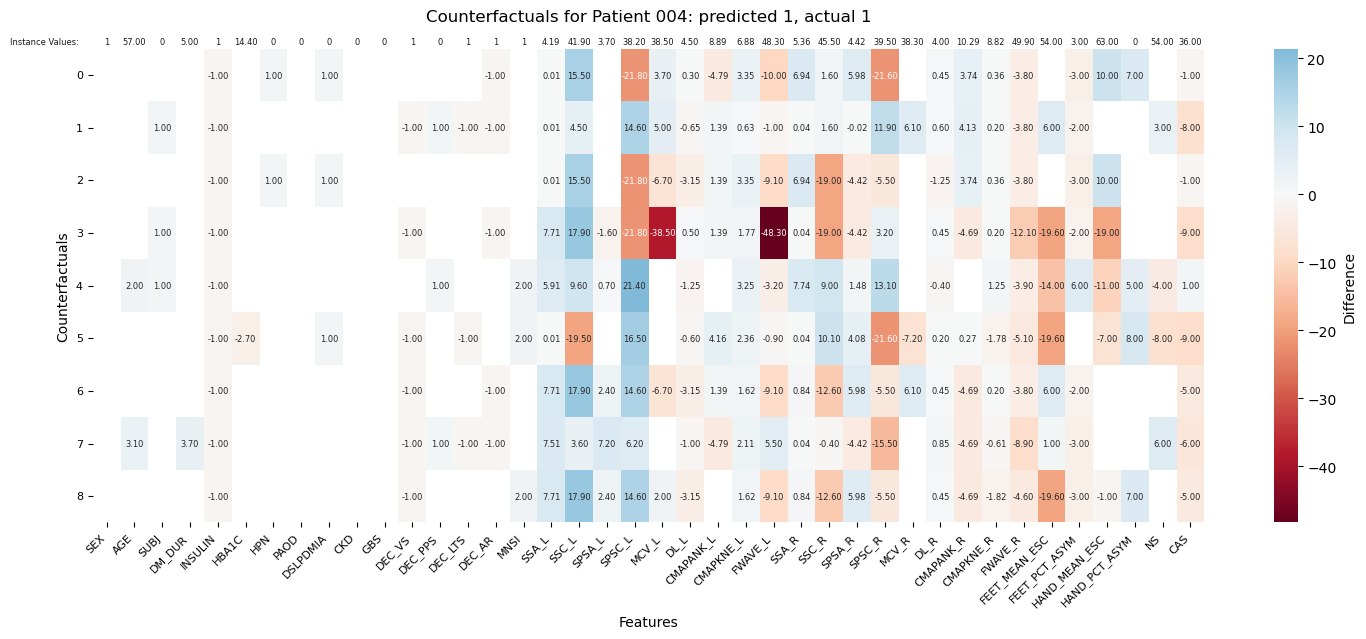

Getting changed features...
Computing Distances...
removing invalid progressive counterfactuals...
Checking for invalid counterfactuals in these columns:
 ['CKD', 'PAOD', 'DEC_PPS', 'HPN', 'GBS', 'DEC_VS', 'DEC_LTS', 'DEC_AR']
Removed 7 invalid progressive counterfactuals
Getting changed features...
Computing Distances...


In [49]:
for qidx in qindices[:1]: 
    print(f"Generating counterfactual analysis for record {qidx}")
    cf.generate_local_cf_reports(dfXy, dexp, ioi_df, qidx, 
                              features_to_vary=dfXy.columns.drop(['SEX', 'Confirmed_Binary_DPN']).to_list(), 
                              config=config,
                              allfeature_cols=allfeature_cols,
                              categorical_cols=D.categorical_cols,
                              continuous_cols=continuous_cols,
                              split_index=midx,
                              total_CFs=10, #30
                              nrepeats=1, # 5
                              savedir=split_output_dir
                              )


## Final Script

In [46]:
from utils2 import counterfactuals as cf

### TO DO: Prototypical and Atypical
- Prototypical (most representative)
- Atypical (deviating from standard/common)